# Analítica de Dados Empresariais
# Mestrado em Ciência de Dados para Empresas
## Machine Learning – Previsão de Telco Churn (Random Forest)

## 1. Importação das bibliotecas

In [1]:
# Ignorar avisos menos relevantes
import warnings
warnings.filterwarnings("ignore")

# Bibliotecas principais de análise
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from pandas.api.types import CategoricalDtype
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Avaliação
from sklearn.metrics import confusion_matrix, classification_report


## 2. Carregar o dataset

In [2]:
#Precisamos desta biblioteca para podermos escolher um ficheiro local
#Se o ficheiro vier por API ou tivermos um link, é so alterar a forma de import
from google.colab import files

# 1️⃣ Faz upload do ficheiro (vai abrir uma janela para escolher no teu PC)
uploaded = files.upload()

# 2️⃣ Guarda o nome do ficheiro (Colab mostra o nome depois do upload)
filename = list(uploaded.keys())[0]

# 3️⃣ Lê o Excel, por default lê sempre a primeira tab, por isso podemos usar o "sheet_name"
# Se tivermos dados em varias tabs, devemos usar uma Dataframe(df) para cada uma das tabs
df = pd.read_excel(filename, sheet_name='tab1')
df.head()

print("Dataset carregado com sucesso")
print("Dimensão:", df.shape)

print("\nPrimeiras linhas:")
print(df.head().to_string(index=False))

Saving WA_Fn-UseC_-Telco-Customer-Churn_CleanData.xlsx to WA_Fn-UseC_-Telco-Customer-Churn_CleanData.xlsx
Dataset carregado com sucesso
Dimensão: (7043, 21)

Primeiras linhas:
customerID gender  SeniorCitizen Partner Dependents  tenure PhoneService    MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies       Contract PaperlessBilling             PaymentMethod  MonthlyCharges  TotalCharges  Churn
7590-VHVEG Female              0     Yes         No       1           No No phone service             DSL             No          Yes               No          No          No              No Month-to-month              Yes          Electronic check           29.85         29.85      0
5575-GNVDE   Male              0      No         No      34          Yes               No             DSL            Yes           No              Yes          No          No              No       One year               No              Mailed check    

## 3. Compreender e limpar os dados

In [3]:
print("Número de clientes:", len(df))

print("\nInformação estrutural:")
df.info()

print("\nTipos de dados:")
print(df.dtypes)

Número de clientes: 7043

Informação estrutural:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object

## 4. Divisão treino/teste

In [4]:
# Selecionar X sem ClientID e Outcome
X = df.drop(["customerID", "Churn"], axis=1)
y = df["Churn"]

# Transformar colunas categóricas em variáveis dummy
X = pd.get_dummies(X, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=123
)

## 5. Construção do modelo

In [24]:
# Criar modelo
rf_model = rf_model = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=123
)
# Treinar modelo
rf_model.fit(X_train, y_train)

# Ver modelo
print(rf_model)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=500, random_state=123)


SeniorCitizen: 0.0099
tenure: 0.1935
MonthlyCharges: 0.0919
TotalCharges: 0.1370
gender_Male: 0.0124
Partner_Yes: 0.0123
Dependents_Yes: 0.0116
PhoneService_Yes: 0.0041
MultipleLines_No phone service: 0.0040
MultipleLines_Yes: 0.0103
InternetService_Fiber optic: 0.0813
InternetService_No: 0.0158
OnlineSecurity_No internet service: 0.0152
OnlineSecurity_Yes: 0.0323
OnlineBackup_No internet service: 0.0151
OnlineBackup_Yes: 0.0129
DeviceProtection_No internet service: 0.0139
DeviceProtection_Yes: 0.0094
TechSupport_No internet service: 0.0138
TechSupport_Yes: 0.0289
StreamingTV_No internet service: 0.0129
StreamingTV_Yes: 0.0084
StreamingMovies_No internet service: 0.0137
StreamingMovies_Yes: 0.0113
Contract_One year: 0.0386
Contract_Two year: 0.1076
PaperlessBilling_Yes: 0.0154
PaymentMethod_Credit card (automatic): 0.0080
PaymentMethod_Electronic check: 0.0516
PaymentMethod_Mailed check: 0.0069


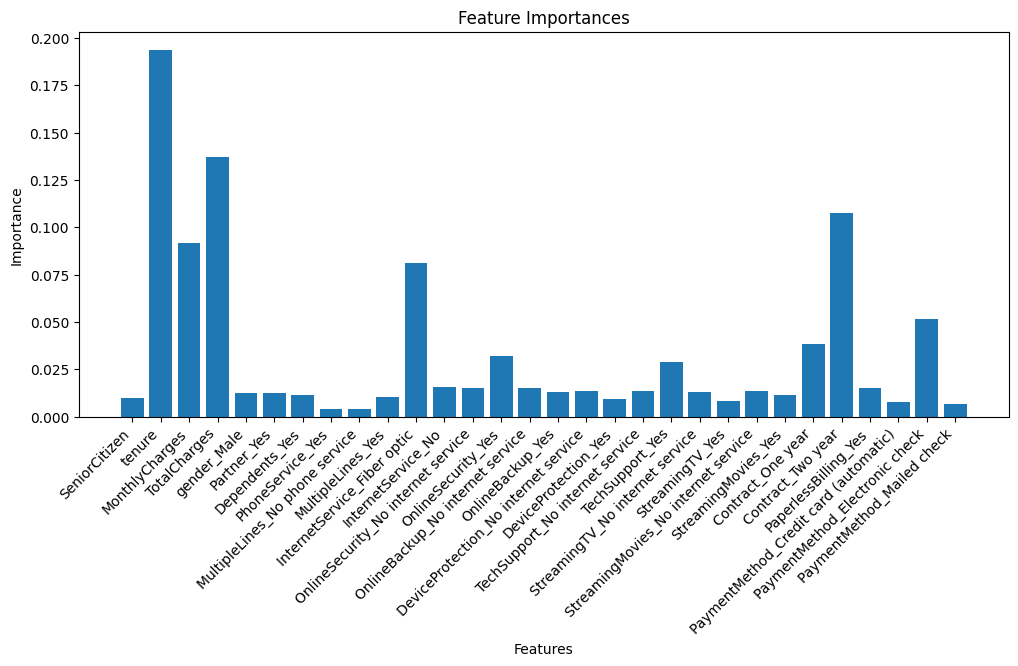

Confusion Matrix:
[[1232  320]
 [ 142  419]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1552
           1       0.57      0.75      0.64       561

    accuracy                           0.78      2113
   macro avg       0.73      0.77      0.74      2113
weighted avg       0.81      0.78      0.79      2113


One Client:
[1]


In [25]:
# 1Importância das features
importances = rf_model.feature_importances_
for name, importance in zip(X_train.columns, importances):
    print(f"{name}: {importance:.4f}")

plt.figure(figsize=(12,5))
plt.bar(X_train.columns, importances)
plt.title("Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')  # rótulos girados para melhor leitura
plt.show()

# Fazer previsões no conjunto de teste
predictions = rf_model.predict(X_test)

predict_One_Client = rf_model.predict(X_test.iloc[[4]])


# Avaliar modelo
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))
print("\nOne Client:")
print(predict_One_Client)

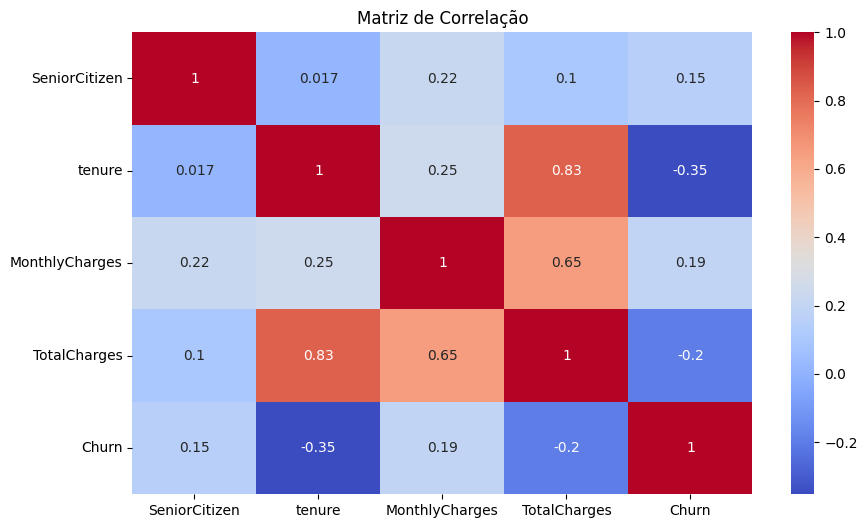

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')

plt.show()

## 6. Cálculo do risco de churn (Decision Engine)

In [27]:
df_scored=df.copy()

#0 no Churn é não, enquanto 1 é Sim/Churn
print("Maior risco:",df_scored["Churn"].max())

print(df_scored[["customerID","Churn"]].head().to_string(index=False))

Maior risco: 1
customerID  Churn
7590-VHVEG      0
5575-GNVDE      0
3668-QPYBK      1
7795-CFOCW      0
9237-HQITU      1


In [28]:
def action(r):

    if r == 1:
        return "Intervenção urgente (oferta forte / contacto direto)"

    return "Campanha de retenção (desconto / benefício)"

df_scored["Recomendacao"] = df_scored["Churn"].apply(action)

print(df_scored["Recomendacao"].value_counts())

Recomendacao
Campanha de retenção (desconto / benefício)             5174
Intervenção urgente (oferta forte / contacto direto)    1869
Name: count, dtype: int64


In [32]:
# Matriz de confusão simples
cm = confusion_matrix(y_test, predictions)
cm_df = pd.DataFrame(cm, index=[0,1], columns=[0,1])  # garantir a ordem das classes
print("Confusion Matrix:")
print(cm_df)

# 2Métricas detalhadas (precisão, recall, F1, suporte)
report = classification_report(y_test, predictions)
print("\nClassification Report:")
print(report)

Confusion Matrix:
      0    1
0  1232  320
1   142  419

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1552
           1       0.57      0.75      0.64       561

    accuracy                           0.78      2113
   macro avg       0.73      0.77      0.74      2113
weighted avg       0.81      0.78      0.79      2113



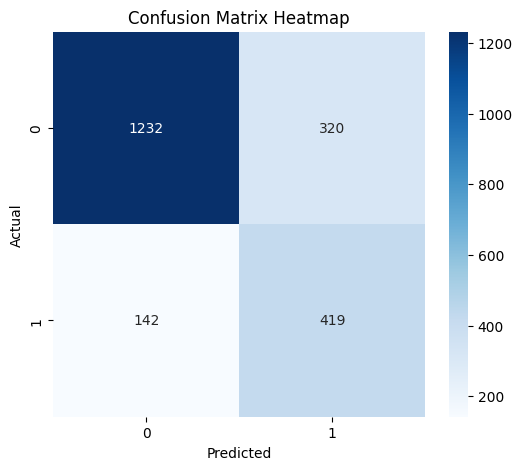

In [33]:
# Gerar matriz de confusão
cm = confusion_matrix(y_test, predictions, labels=y_test.unique())

# Criar DataFrame para labels
cm_df = pd.DataFrame(cm, index=y_test.unique(), columns=y_test.unique())

# Plotar heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix Heatmap")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

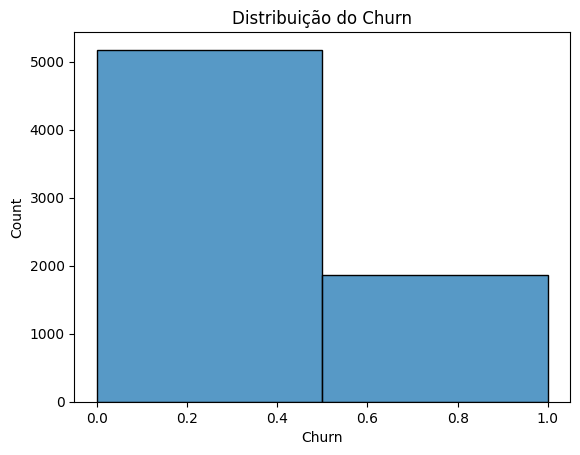

In [35]:
sns.histplot(df_scored["Churn"],bins=2)
plt.title("Distribuição do Churn")
plt.show()

## 7. Distribuição das estratégias

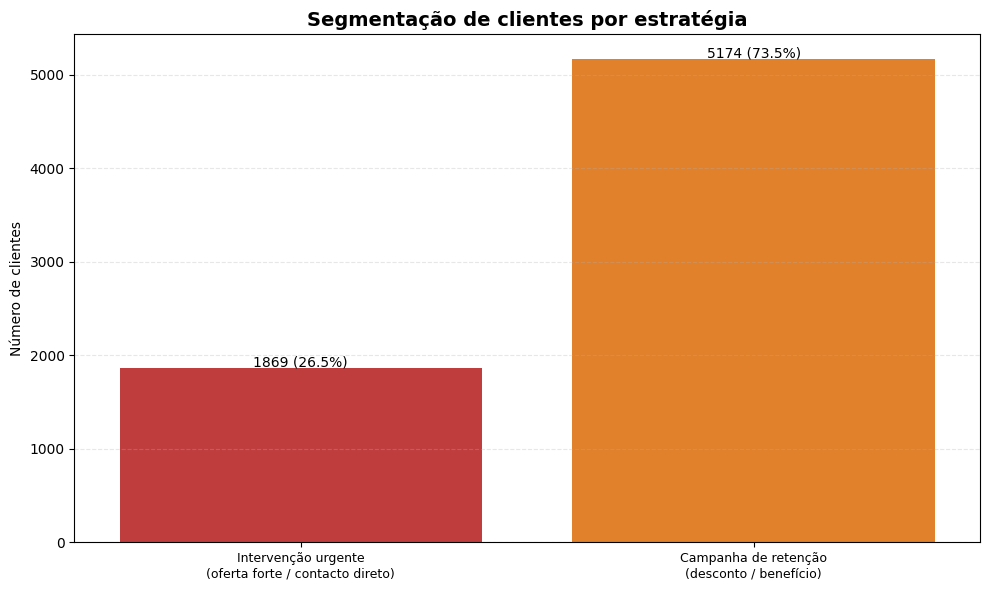

In [37]:
# Contagem e ordenação por nível de risco
ordem = [
    "Intervenção urgente (oferta forte / contacto direto)",
    "Campanha de retenção (desconto / benefício)"
]

# Criar cópia apenas para melhorar os rótulos do gráfico
df_plot = df_scored.copy()

df_plot["Recomendacao_plot"] = df_plot["Recomendacao"].replace({
    "Intervenção urgente (oferta forte / contacto direto)":"Intervenção urgente (oferta forte / contacto direto)",
    "Campanha de retenção (desconto / benefício)": "Campanha de retenção (desconto / benefício)"
})

counts = df_plot["Recomendacao_plot"].value_counts().reindex(ordem)

# Percentagens
percent = counts / counts.sum() * 100

# Cores por criticidade
cores = ["#d62728", "#ff7f0e"]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    palette=cores
)

plt.title("Segmentação de clientes por estratégia", fontsize=14, weight="bold")
plt.xlabel("")
plt.ylabel("Número de clientes")

# alterar labels do eixo X
labels = [
    "Intervenção urgente\n(oferta forte / contacto direto)",
    "Campanha de retenção\n(desconto / benefício)"
]

ax.set_xticklabels(labels, fontsize=9)

# Valores e percentagens
for i, (val, pct) in enumerate(zip(counts.values, percent)):
    ax.text(i, val + 8, f"{val} ({pct:.1f}%)", ha="center", fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()